Upload bank-full.csv


Saving bank-full.csv to bank-full (1).csv

========== FIRST 5 ROWS ==========
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

========== SHAPE ==========
(452

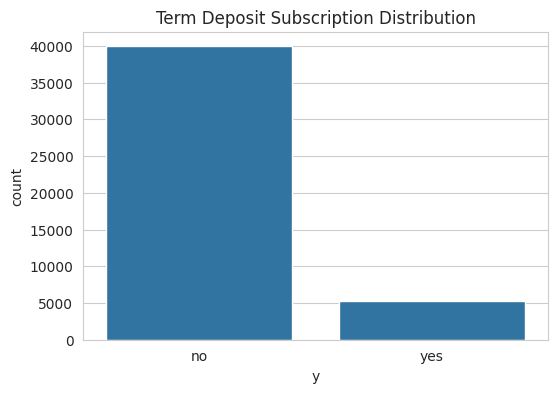

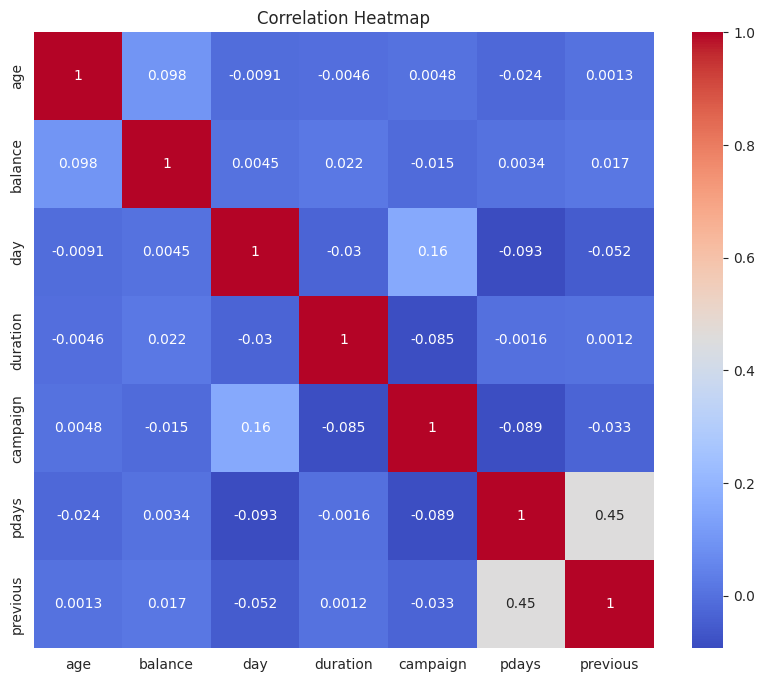


Categorical features encoded successfully.

Feature Matrix Shape: (45211, 16)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.59      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043

F1 Score: 0.31197771587743733

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043

F1 Score: 0.5005834305717619


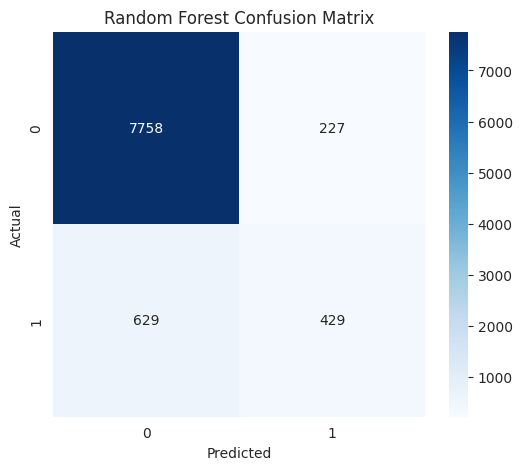

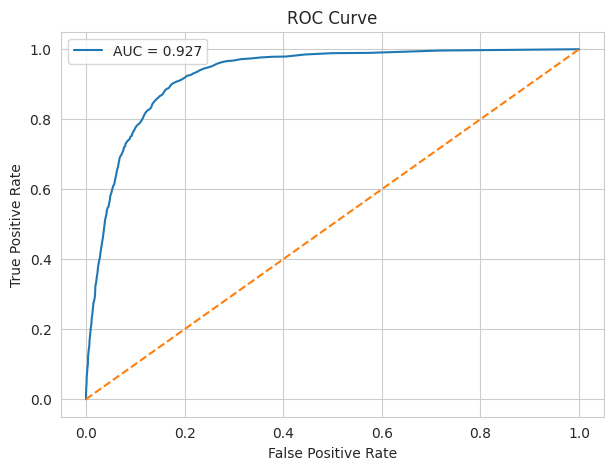


ROC AUC Score: 0.9270504833614066

Top 10 Important Features
      Feature  Importance
11   duration    0.292823
5     balance    0.109880
0         age    0.103779
9         day    0.090144
10      month    0.087234
15   poutcome    0.053442
13      pdays    0.048938
1         job    0.048624
12   campaign    0.038628
3   education    0.027604


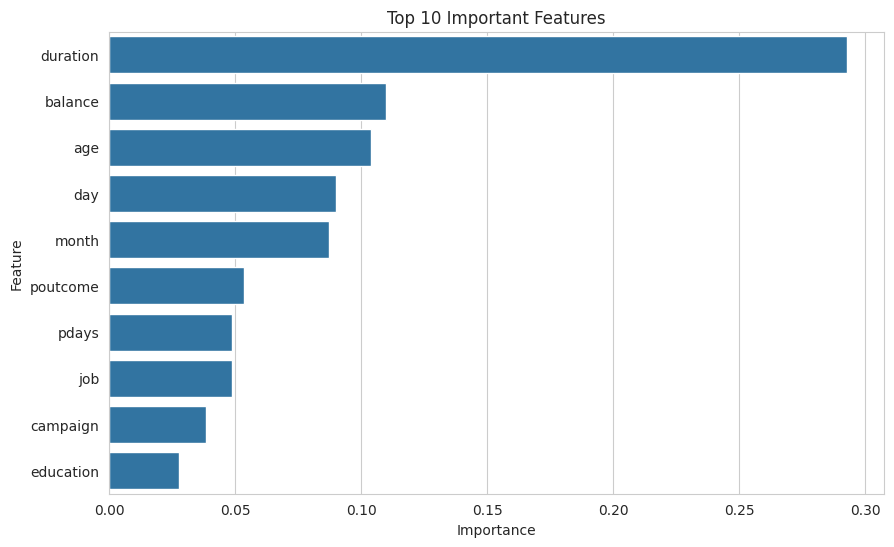

In [ ]:
# ==========================================================
# TASK 1: TERM DEPOSIT SUBSCRIPTION PREDICTION
# DevelopersHub Data Science Internship
# ==========================================================

# Install SHAP
!pip install shap -q

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)

sns.set_style("whitegrid")

# ==========================================================
# UPLOAD DATASET
# ==========================================================

print("Upload bank-full.csv")

uploaded = files.upload()

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("bank-full.csv", sep=";")

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== SHAPE ==========")
print(df.shape)

print("\n========== DATA INFO ==========")
print(df.info())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df.describe(include="all"))

# ==========================================================
# TARGET VARIABLE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Term Deposit Subscription Distribution")
plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# LABEL ENCODING
# ==========================================================

label_encoders = {}

for col in df.columns:

    if df[col].dtype == "object":

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col])

        label_encoders[col] = le

print("\nCategorical features encoded successfully.")

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop("y", axis=1)
y = df["y"]

print("\nFeature Matrix Shape:", X.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

lr = LogisticRegression(
    max_iter=2000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

print(classification_report(
    y_test,
    lr_pred
))

print("F1 Score:",
      f1_score(y_test, lr_pred))

# ==========================================================
# RANDOM FOREST
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")

print(classification_report(
    y_test,
    rf_pred
))

print("F1 Score:",
      f1_score(y_test, rf_pred))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================

rf_probs = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(
    y_test,
    rf_probs
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print("\nROC AUC Score:", auc)

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")
print(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# ==========================================================
# SHAP EXPLAINABILITY
# ==========================================================

print("\nGenerating SHAP explanations...")

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

# ==========================================================
# SHAP SUMMARY PLOT
# ==========================================================

shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

# ==========================================================
# EXPLAIN 5 INDIVIDUAL PREDICTIONS
# ==========================================================

for i in range(5):

    print(f"\n\n===== EXPLANATION FOR PREDICTION {i+1} =====")

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[i,:,1],
            base_values=explainer.expected_value[1],
            data=X_test.iloc[i],
            feature_names=X_test.columns
        )
    )

# ==========================================================
# FINAL INSIGHTS
# ==========================================================

print("\n==============================")
print("FINAL CONCLUSION")
print("==============================")

print("""
Random Forest achieved strong performance in predicting
term deposit subscriptions.

The most influential features were identified through
feature importance and SHAP analysis.

The model can help banks identify customers who are more
likely to subscribe to term deposits and improve
marketing campaign effectiveness.
""")